In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt,seaborn as sns
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler,FunctionTransformer,PowerTransformer,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn import metrics
from xgboost import XGBClassifier
import optuna
from transforms import AgeImputer,FeatureEngineering
import joblib

In [27]:
df= pd.read_csv('data/raw/titanic.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
num_cols = ['Fare']
cat_cols = ['Pclass','SibSp','Parch']
cat_ohe_cols = ['Embarked','Sex','Age_group']
drop =['Cabin','PassengerId','Name','Ticket']


num_pipe = Pipeline([
    ('Num_impute',KNNImputer(weights='distance')),
    ('scale',StandardScaler())
])
cat_pipe = Pipeline([
    ('cat_impute',SimpleImputer(strategy='most_frequent'))
])
ohe_pipe = Pipeline([
    ('cat_ohe_impute',SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(sparse_output=False,handle_unknown='ignore',drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num_impute',num_pipe,num_cols),
    ('cat_impute',cat_pipe,cat_cols),
    ('ohe',ohe_pipe,cat_ohe_cols),
    ('drop','drop',drop),
],
                                 remainder='passthrough',
                                 verbose_feature_names_out=False,
                                 n_jobs=-1
                                )



In [4]:
Model1 = Pipeline([
    ('ageImputer',AgeImputer()),
    ('featureEngineering',FeatureEngineering()),
    ('preprocessor',preprocessor),
    ('lgr',LogisticRegression(max_iter=300))
])

In [5]:
X= df.drop('Survived',axis=1)
y=df.Survived

In [6]:
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [7]:
print(y_train.value_counts(),y_test.value_counts())

Survived
0    374
1    222
Name: count, dtype: int64 Survived
0    175
1    120
Name: count, dtype: int64


In [8]:
Model1.fit(X_train,y_train)

,steps,"[('ageImputer', ...), ('featureEngineering', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputer,'knn'
,transformers,"[('num_impute', ...), ('cat_impute', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False


In [9]:
y_pred = Model1.predict(X_test)

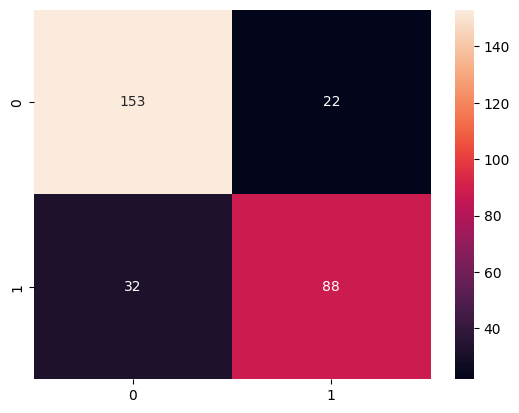

82.0 % accuracy


In [10]:
cm = metrics.confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.show()
print(round(metrics.accuracy_score(y_test,y_pred)*100,0),"% accuracy")

In [11]:
print(metrics.classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       175
           1       0.80      0.73      0.77       120

    accuracy                           0.82       295
   macro avg       0.81      0.80      0.81       295
weighted avg       0.82      0.82      0.82       295



In [12]:
#cross val score
lgr_score = cross_val_score(Model1,X,y,scoring='accuracy',cv=10,n_jobs=-1)

In [13]:
print("lgr cross val score \nmean: ",lgr_score.mean())
print("Std: ",lgr_score.std())

lgr cross val score 
mean:  0.8013233458177279
Std:  0.02211311570624339




### - Logistic Regression is used as a baseline model to establish a reliable performance benchmark. More complex models will be evaluated next to assess potential improvements.

In [14]:
models = {
    'rf' : Pipeline([
    ('ageImputer',AgeImputer()),
    ('featureEngineering',FeatureEngineering()),
    ('preprocessor',preprocessor),
    ('rf',RandomForestClassifier(random_state=42))
]),
    'xgb': Pipeline([
    ('ageImputer',AgeImputer()),
    ('featureEngineering',FeatureEngineering()),
    ('preprocessor',preprocessor),
    ('xgb',XGBClassifier())
]),
    'gb': Pipeline([
    ('ageImputer',AgeImputer()),
    ('featureEngineering',FeatureEngineering()),
    ('preprocessor',preprocessor),
    ('gb',GradientBoostingClassifier(random_state=42))
])
}

### Hyperparameters were optimized using Optuna, and the best configurations were directly injected into the final pipelines for retraining and evaluation.

In [15]:
def objective(trial, model_name, X, y):

    if model_name == 'rf':
        params = {
            'rf__n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'rf__max_depth': trial.suggest_int('max_depth', 5, 30),
            'rf__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'rf__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'rf__max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
        }

        model = models['rf'].set_params(**params)

    elif model_name == 'xgb':
        params = {
            'xgb__n_estimators': trial.suggest_int('n_estimators', 100, 600),
            'xgb__max_depth': trial.suggest_int('max_depth', 3, 12),
            'xgb__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'xgb__subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'xgb__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'xgb__gamma': trial.suggest_float('gamma', 0, 5)
        }

        model = models['xgb'].set_params(**params)

    elif model_name == 'gb':
        params = {
            'gb__n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'gb__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'gb__max_depth': trial.suggest_int('max_depth', 3, 10),
            'gb__min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'gb__min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10)
        }

        model = models['gb'].set_params(**params)

    score = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    ).mean()

    return score


In [16]:
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(lambda trial: objective(trial, 'rf', X, y), n_trials=50)

print("Best RF params:", study_rf.best_params)
print("Best RF score:", study_rf.best_value)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(lambda trial: objective(trial, 'xgb', X, y), n_trials=50)

print("Best XGB params:", study_xgb.best_params)
print("Best XGB score:", study_xgb.best_value)

study_gb = optuna.create_study(direction='maximize')
study_gb.optimize(lambda trial: objective(trial, 'gb', X, y), n_trials=50)

print("Best GB params:", study_gb.best_params)
print("Best GB score:", study_gb.best_value)


[I 2025-12-30 19:04:31,569] A new study created in memory with name: no-name-8a2ae77d-070a-4e2e-8109-6c0638620c0c
[I 2025-12-30 19:04:33,653] Trial 0 finished with value: 0.820475801895675 and parameters: {'n_estimators': 298, 'max_depth': 16, 'min_samples_split': 19, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.820475801895675.
[I 2025-12-30 19:04:36,126] Trial 1 finished with value: 0.8159939740129308 and parameters: {'n_estimators': 316, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.820475801895675.
[I 2025-12-30 19:04:37,561] Trial 2 finished with value: 0.8249576297784195 and parameters: {'n_estimators': 176, 'max_depth': 27, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 2 with value: 0.8249576297784195.
[I 2025-12-30 19:04:38,963] Trial 3 finished with value: 0.8182411650241669 and parameters: {'n_estimators': 181, 'max_depth': 13, 'm

Best RF params: {'n_estimators': 122, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}
Best RF score: 0.8328165212478815


[I 2025-12-30 19:05:53,039] Trial 0 finished with value: 0.8159625886636117 and parameters: {'n_estimators': 163, 'max_depth': 6, 'learning_rate': 0.04100177266834784, 'subsample': 0.8090485126445781, 'colsample_bytree': 0.6514285016025697, 'gamma': 3.8913234906075655}. Best is trial 0 with value: 0.8159625886636117.
[I 2025-12-30 19:05:54,479] Trial 1 finished with value: 0.8159374803841567 and parameters: {'n_estimators': 259, 'max_depth': 12, 'learning_rate': 0.014032939510177086, 'subsample': 0.6986648153930484, 'colsample_bytree': 0.8610373368035595, 'gamma': 4.703975422960099}. Best is trial 0 with value: 0.8159625886636117.
[I 2025-12-30 19:05:55,431] Trial 2 finished with value: 0.8148264390182662 and parameters: {'n_estimators': 166, 'max_depth': 12, 'learning_rate': 0.028008213448868887, 'subsample': 0.6645539323821753, 'colsample_bytree': 0.7676925442804274, 'gamma': 3.9580771609028}. Best is trial 0 with value: 0.8159625886636117.
[I 2025-12-30 19:05:55,939] Trial 3 finishe

Best XGB params: {'n_estimators': 134, 'max_depth': 6, 'learning_rate': 0.04768455921394668, 'subsample': 0.7731503669519116, 'colsample_bytree': 0.9205375071031117, 'gamma': 0.28289737284728517}
Best XGB score: 0.8395141547925429


[I 2025-12-30 19:06:23,209] Trial 0 finished with value: 0.8238089259933463 and parameters: {'n_estimators': 108, 'learning_rate': 0.040293045178190386, 'max_depth': 4, 'min_samples_split': 16, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.8238089259933463.
[I 2025-12-30 19:06:25,265] Trial 1 finished with value: 0.8395267089322704 and parameters: {'n_estimators': 325, 'learning_rate': 0.06802952640138901, 'max_depth': 3, 'min_samples_split': 15, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8395267089322704.
[I 2025-12-30 19:06:30,627] Trial 2 finished with value: 0.8013684012303057 and parameters: {'n_estimators': 327, 'learning_rate': 0.12503376172569933, 'max_depth': 9, 'min_samples_split': 17, 'min_samples_leaf': 2}. Best is trial 1 with value: 0.8395267089322704.
[I 2025-12-30 19:06:33,265] Trial 3 finished with value: 0.8282907538760906 and parameters: {'n_estimators': 417, 'learning_rate': 0.019135837613181855, 'max_depth': 3, 'min_samples_split': 5, 'min_sample

Best GB params: {'n_estimators': 339, 'learning_rate': 0.08499242036436776, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 4}
Best GB score: 0.8417801770133702


In [17]:
best_rf_params  = study_rf.best_params
best_xgb_params = study_xgb.best_params
best_gb_params  = study_gb.best_params
print(best_rf_params)
print(best_xgb_params)
print(best_gb_params)

{'n_estimators': 122, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}
{'n_estimators': 134, 'max_depth': 6, 'learning_rate': 0.04768455921394668, 'subsample': 0.7731503669519116, 'colsample_bytree': 0.9205375071031117, 'gamma': 0.28289737284728517}
{'n_estimators': 339, 'learning_rate': 0.08499242036436776, 'max_depth': 3, 'min_samples_split': 3, 'min_samples_leaf': 4}


In [18]:
rf_best_pipeline = Pipeline([
    ('ageImputer', AgeImputer()),
    ('featureEngineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(
        **best_rf_params,
        random_state=42,
        n_jobs=-1
    ))
])
xgb_best_pipeline = Pipeline([
    ('ageImputer', AgeImputer()),
    ('featureEngineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(
        **best_xgb_params,
        random_state=42,
        eval_metric='logloss'
    ))
])
gb_best_pipeline = Pipeline([
    ('ageImputer', AgeImputer()),
    ('featureEngineering', FeatureEngineering()),
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(
        **best_gb_params,
        random_state=42
    ))
])

In [19]:
rf_best_pipeline.fit(X_train, y_train)

,steps,"[('ageImputer', ...), ('featureEngineering', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputer,'knn'
,transformers,"[('num_impute', ...), ('cat_impute', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False


In [20]:
xgb_best_pipeline.fit(X_train, y_train)

,steps,"[('ageImputer', ...), ('featureEngineering', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputer,'knn'
,transformers,"[('num_impute', ...), ('cat_impute', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False


In [21]:
gb_best_pipeline.fit(X_train, y_train)

,steps,"[('ageImputer', ...), ('featureEngineering', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,imputer,'knn'
,transformers,"[('num_impute', ...), ('cat_impute', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,-1
,transformer_weights,None
,verbose,False


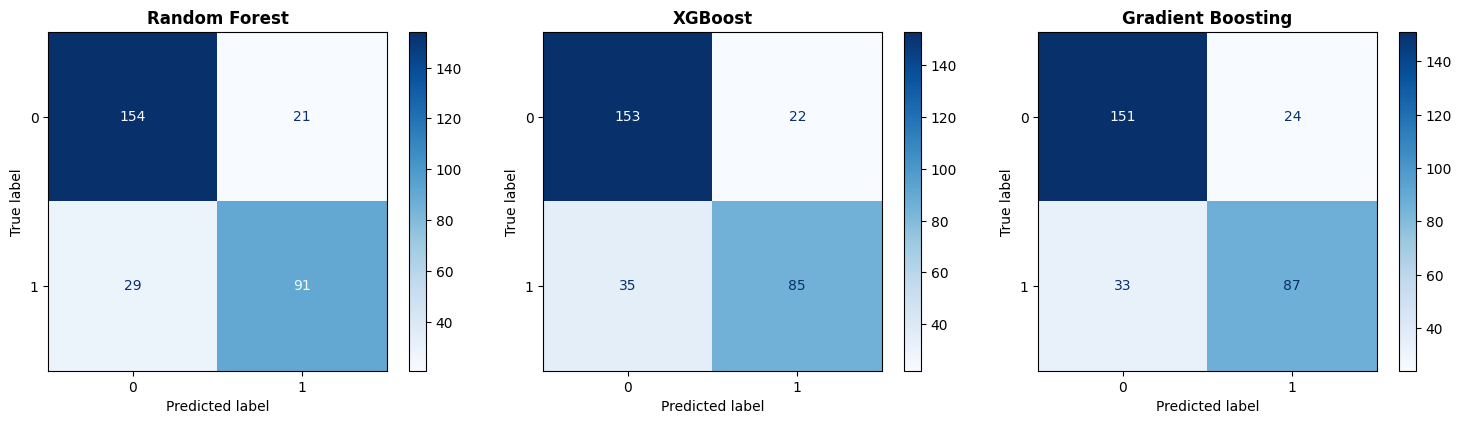

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    (rf_best_pipeline, "Random Forest"),
    (xgb_best_pipeline, "XGBoost"),
    (gb_best_pipeline, "Gradient Boosting")
]

for ax, (model, name) in zip(axes, models):
    metrics.ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        cmap='Blues',
        values_format='d'
    )
    ax.set_title(name, fontweight='bold')

plt.tight_layout()
plt.show()



In [23]:
def classification_report_df(model, X_test, y_test, model_name):
    report = metrics.classification_report(
        y_test,
        model.predict(X_test),
        output_dict=True
    )
    df = pd.DataFrame(report).T
    df['model'] = model_name
    return df

In [24]:
reports_df = pd.concat([
    classification_report_df(rf_best_pipeline, X_test, y_test, "Random Forest"),
    classification_report_df(xgb_best_pipeline, X_test, y_test, "XGBoost"),
    classification_report_df(gb_best_pipeline, X_test, y_test, "Gradient Boosting")
])

In [25]:
reports_df

,precision,recall,f1-score,support,model
0,0.841530,0.880000,0.860335,175.000000,Random Forest
1,0.812500,0.758333,0.784483,120.000000,Random Forest
accuracy,0.830508,0.830508,0.830508,0.830508,Random Forest
macro avg,0.827015,0.819167,0.822409,295.000000,Random Forest
weighted avg,0.829721,0.830508,0.829480,295.000000,Random Forest
0,0.813830,0.874286,0.842975,175.000000,XGBoost
1,0.794393,0.708333,0.748899,120.000000,XGBoost
accuracy,0.806780,0.806780,0.806780,0.806780,XGBoost
macro avg,0.804111,0.791310,0.795937,295.000000,XGBoost
weighted avg,0.805923,0.806780,0.804707,295.000000,XGBoost


In [26]:
joblib.dump(rf_best_pipeline,"models/final_rf_pipeline.joblib")

['models/final_rf_pipeline.joblib']